# RyR Expression-Level Calcium Traces

Presynaptic cytosolic, active-zone, and ER calcium (plus RyR flux) compared
across RyR expression conditions — control, AD + 5x RyR overexpression, and
AD + 1/2x RyR underexpression — for a paired-pulse stimulus (40 ms ISI).


In [1]:
import os
import re

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.optimize import curve_fit

from plot_config import (
    PALETTE,
    get_condition,
    apply_style,
    strip_spines,
    panel_labeler,
    label_panel,
    set_n_ticks,
    set_nice_ticks,
    add_zoom_inset,
    save_figure,
)

apply_style()

## Configuration


In [ ]:
CONDITION_DIRS = {
    "control": "/data/hdrive/phd/results/prvsppf_experiments/MI_cont/RSI40V80C250uM_nish2sur_nishRyR",
    "ad_5x_ryr": "/data/hdrive/phd/results/prvsppf_experiments/AD_RyR_overexp_PSblocked_vdcc_vs_ppf/RSI40V80C750uM_5xryr_nish2sur_nishRyR",
    "ad_half_ryr": "/data/hdrive/phd/results/prvsppf_experiments/AD_RyR_underexp_PSblocked_vdcc_vs_ppf/RSI40V80C750uM_nish_1_2xryr_nish2sur_nishRyR",
}
CONDITION_ORDER = ["control", "ad_5x_ryr", "ad_half_ryr"] 

FILES = {
    "Pre": "pre_ca_conc.dat",
    "AZ": "CaConc",
    "ER": "er_ca_conc.dat",
    "RyR": "ryrCaFluxRate.dat",
}

UNIT_SCALE = {
    "Pre": 1e-3,   # nM -> uM
    "RyR": 1e-6,   # ions/ms -> 10^6 ions/ms
}

COMPARTMENTS = [
    ("Pre", True),
    ("AZ", True),
    ("ER", True),
]
compartments = [name for name, show in COMPARTMENTS if show]

ylabels = {
    "Pre": r"Cytosolic [$Ca^{2+}$] ($\mu$M)",
    "AZ": r"AZ [$Ca^{2+}$] ($\mu$M)",
    "ER": r"ER [$Ca^{2+}$] ($\mu$M)",
}

# Time windows, in ms. FULL_WINDOW=None -> full extent of the loaded data,
# shared across all rows so every panel lines up on the same time axis.
FULL_WINDOW = None
PULSE_WINDOWS = [
    ("Pulse 1", (1, 4)),
    ("Pulse 2", (41, 44)),
]

INSET_RECTS = [
    (0.13, 0.54, 0.20, 0.42),
    (0.79, 0.54, 0.20, 0.42),
]

INSET_COMPARTMENTS = {
    "Pre": True,
    "AZ": True,
    "ER": False,
}
SHOW_ZOOM_CONNECTORS = True     
INSET_SHOW_YTICKLABELS = False 

N_AXIS_TICKS = 3    
N_INSET_XTICKS = 2 

N_COLS = 2
N_PANELS = len(compartments) + 5  # + RyR, Pr1-vs-PPF, Pr2-vs-PPF, PPF-vs-ISI, vesicle release
N_ROWS = -(-N_PANELS // N_COLS)  # ceil division

FIGSIZE = (10.5, 2.15 * N_ROWS + 1.2)

SAVE_FIGURE = True
FIGURE_PATH = "fig5_RyR_paired_pulse_facilitation.png"

## Load data

In [3]:
def load_trace(path):
    data = np.loadtxt(path, comments="#")
    if data.ndim == 1:
        data = data.reshape(1, -1)
    return data[:, 0] * 1000.0, data[:, 1]  # s -> ms


def load_condition(base_dir):
    traces = {}
    for compartment, fname in FILES.items():
        t, y = load_trace(os.path.join(base_dir, fname))
        traces[compartment] = (t, y * UNIT_SCALE.get(compartment, 1.0))
    return traces


data_by_condition = {key: load_condition(path) for key, path in CONDITION_DIRS.items()}
datasets = [(key, get_condition(key), data_by_condition[key]) for key in CONDITION_ORDER]


def full_trace_window():
    """FULL_WINDOW if set, else the shared min/max time across every
    compartment and condition, so every row lines up on the same time axis."""
    if FULL_WINDOW is not None:
        return FULL_WINDOW
    all_t = np.concatenate([t for _, _, data in datasets for t, _ in data.values()])
    return float(all_t.min()), float(all_t.max())

## Pr vs PPF panels (addendum)


In [ ]:
PRPPF_DIR = "/data/hdrive/phd/results/prvsppf_experiments/pr vs ppf"
PRPPF_FILES = {
    "control": f"{PRPPF_DIR}/I40_prvsppf_control",
    "ad_5x_ryr": f"{PRPPF_DIR}/I40_prvsppf_AD",
    "ad_half_ryr": f"{PRPPF_DIR}/I40_prvsppf_AD_1_2xRyR",
}

PR1PPF_XLIM = (0.05, 1.0)
PR2PPF_XLIM = (0.0, 1.0)   # Pr2 runs a bit higher than Pr1 across conditions
PRPPF_YLIM = (1.0, 7.0)    # shared by both Pr1-vs-PPF and Pr2-vs-PPF panels

FIT_LINEWIDTH = 2.5
ERRORBAR_LINEWIDTH = 1.2
MARKERSIZE = 6

PR2_FIT_P0 = [1.0, 5.0, 0.3]  # initial guess for exp_fit's (A, B, tau) on Pr2

# VDCC channel counts to call out with an arrowhead on both panels' curves,
# each with its own color, drawn from plot_config.PALETTE so it stays
# distinct from every condition color.
VDCC_HIGHLIGHTS = {
    80: PALETTE["bluish_green"],
    90: PALETTE["reddish_purple"],
}

ARROW_OFFSET_POINTS = {
    80: (22, 20),
    90: (22, 20),
}

### Load Pr1/Pr2-vs-PPF data

In [5]:
def load_prppf_dataset(path):
    data = np.genfromtxt(path, comments="//", skip_header=1)
    return {
        "vdcc": data[:, 0],
        "pr1": data[:, 1],
        "pr2": data[:, 3],
        "ppf": data[:, 5],
        "std": data[:, 6],   # sd-ppf
    }


prppf_data = {key: load_prppf_dataset(path) for key, path in PRPPF_FILES.items()}


def prppf_point_at(key, vdcc, x_key="pr1"):
    """(x, ppf) for the given condition key at an exact VDCC channel count.
    x_key selects "pr1" or "pr2" as the x-value."""
    d = prppf_data[key]
    idx = np.where(d["vdcc"] == vdcc)[0]
    if idx.size == 0:
        raise ValueError(f"VDCC={vdcc} not found for condition {key!r}.")
    return d[x_key][idx[0]], d["ppf"][idx[0]]


def facilitation_model(x, a, b):
    """Saturating-recovery fit of PPF vs release probability."""
    return (1 - (1 - x) ** (a * x ** b)) / x

## PPF vs ISI panel (addendum)


In [ ]:
ISI_PPF_DIRS = {
    "control": "/data/hdrive/phd/results/prvsppf_experiments/control_ISIvsppf",
    "ad_5x_ryr": "/data/hdrive/phd/results/prvsppf_experiments/model_AD",
    "ad_half_ryr": "/data/hdrive/phd/results/prvsppf_experiments/AD_RyR_underexp_PSblocked",
    "ad_ps_blocked": "/data/hdrive/phd/results/prvsppf_experiments/AD_PSblocked",
}
ISI_CONDITION_ORDER = ["control", "ad_5x_ryr", "ad_half_ryr", "ad_ps_blocked"]
ISI_PPF_VDCC = 90

PLOT_PSBLOCKED = False  # loaded/fit either way; flip to True to draw it too

ISI_SKIP_FIRST = True  # drop the smallest ISI (10 ms) before fitting/plotting
ISI_FIT_P0 = [1.8, 2.0, 80]  # initial guess for exp_fit's (A, B, tau)

ISI_TICKS = [20, 100, 250, 750]
ISI_YLIM = (1, 4.5)
ISI_CAPSIZE = 4

### Load PPF-vs-ISI data

In [7]:
def load_ppf_vs_isi(base_dir, vdcc):
    """{isi: (ppf, std)} for every "RSI{isi}V{vdcc}..." subfolder of base_dir."""
    data = {}
    for folder in os.listdir(base_dir):
        folder_path = os.path.join(base_dir, folder)
        if not os.path.isdir(folder_path):
            continue
        match = re.search(r"RSI(\d+)V(\d+)", folder)
        if match is None or int(match.group(2)) != vdcc:
            continue
        result_file = os.path.join(folder_path, "result")
        if not os.path.exists(result_file):
            continue
        vals = np.atleast_2d(np.loadtxt(result_file))
        ppf = float(vals[0, -1])
        std = float(vals[1, -1]) if vals.shape[0] > 1 else 0.0
        data[int(match.group(1))] = (ppf, std)
    return data


isi_ppf_data = {
    key: load_ppf_vs_isi(path, ISI_PPF_VDCC) for key, path in ISI_PPF_DIRS.items()
}

common_isi = sorted(set.intersection(*(set(d) for d in isi_ppf_data.values())))
if not common_isi:
    raise ValueError("No ISI value is common to every condition in ISI_PPF_DIRS.")
if ISI_SKIP_FIRST:
    common_isi = common_isi[1:]
isi_vals = np.array(common_isi)


def exp_fit(x, A, B, tau):
    return A + B * np.exp(-x / tau)


isi_fits = {}
for key, d in isi_ppf_data.items():
    ppf = np.array([d[i][0] for i in common_isi])
    std = np.array([d[i][1] for i in common_isi])
    params, _ = curve_fit(exp_fit, isi_vals, ppf, p0=ISI_FIT_P0, bounds=(0, np.inf))
    isi_fits[key] = {"ppf": ppf, "std": std, "params": params}

## Vesicle release panel (addendum)


In [ ]:
VESREL_FILENAME = "vesRel"

### Load vesicle release data

In [9]:
def load_vesicle_release_times(base_dir):
    """Sorted release-event times (ms) from the vesRel file in base_dir."""
    path = os.path.join(base_dir, VESREL_FILENAME)
    times = np.genfromtxt(path, usecols=(0,))
    return np.sort(times) * 1000.0  # s -> ms


vesrel_times = {key: load_vesicle_release_times(path) for key, path in CONDITION_DIRS.items()}

## Build figure


/tmp/ipykernel_242901/670639102.py:27: RuntimeWarning: overflow encountered in power
  return (1 - (1 - x) ** (a * x ** b)) / x


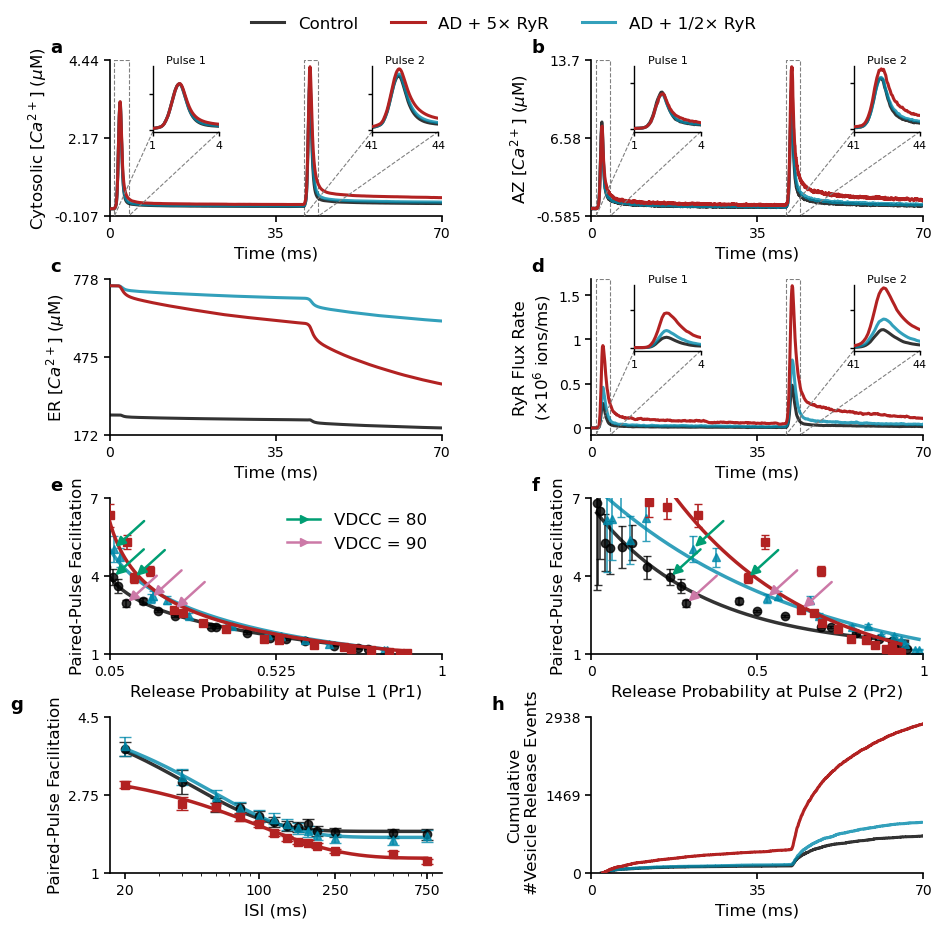

In [ ]:
nrows = len(compartments)
fig, axes = plt.subplots(
    N_ROWS, N_COLS,
    figsize=FIGSIZE,
    gridspec_kw={"height_ratios": [1.0] * N_ROWS},  # uniform: same box aspect ratio everywhere
)
axes_flat = axes.flatten()
for extra_ax in axes_flat[N_PANELS:]:  # hide any unused trailing grid cell
    extra_ax.set_visible(False)

comp_axes = axes_flat[:nrows]
ax_ryr = axes_flat[nrows]
ax_pr1ppf = axes_flat[nrows + 1]
ax_pr2ppf = axes_flat[nrows + 2]
ax_isi = axes_flat[nrows + 3]
ax_vesrel = axes_flat[nrows + 4]

fig.subplots_adjust(hspace=0.40, wspace=0.45, top=0.94)

panel = panel_labeler()
window = full_trace_window()  # shared by every calcium row, compartments and RyR alike

for ax, comp in zip(comp_axes, compartments):
    y_visible = np.concatenate([
        y[(t >= window[0]) & (t <= window[1])]
        for _, _, data in datasets
        for t, y in [data[comp]]
    ])
    pad = 0.05 * (y_visible.max() - y_visible.min() or 1)
    ylim = (y_visible.min() - pad, y_visible.max() + pad)

    for _, cond, data in datasets:
        t, y = data[comp]
        m = (t >= window[0]) & (t <= window[1])
        ax.plot(t[m], y[m], color=cond.color, linestyle=cond.linestyle,
                 alpha=cond.alpha, zorder=cond.zorder, label=cond.label)

    ax.set_xlim(*window)
    ax.set_ylim(*ylim)
    set_n_ticks(ax, *window, n=N_AXIS_TICKS, axis="x")
    set_n_ticks(ax, *ylim, n=N_AXIS_TICKS, axis="y")
    strip_spines(ax)
    ax.set_ylabel(ylabels[comp])
    ax.set_xlabel("Time (ms)")  
    label_panel(ax, next(panel))

    if INSET_COMPARTMENTS.get(comp, True):
        for (pulse_label, pulse_window), rect in zip(PULSE_WINDOWS, INSET_RECTS):
            traces = [(data[comp][0], data[comp][1], cond) for _, cond, data in datasets]
            add_zoom_inset(
                ax, traces, pulse_window, rect,
                ylim=ylim,
                n_xticks=N_INSET_XTICKS,
                show_yticklabels=INSET_SHOW_YTICKLABELS,
                connector=SHOW_ZOOM_CONNECTORS,
                title=pulse_label,
            )

calcium_handles, calcium_labels = comp_axes[0].get_legend_handles_labels()
fig.legend(calcium_handles, calcium_labels, loc="upper center", ncol=len(datasets),
           frameon=False, bbox_to_anchor=(0.5, 1.0))

# ------------------------------------------------------------------
# RyR flux 
# ------------------------------------------------------------------
y_visible = np.concatenate([
    y[(t >= window[0]) & (t <= window[1])]
    for _, _, data in datasets
    for t, y in [data["RyR"]]
])
pad = 0.05 * (y_visible.max() - y_visible.min() or 1)
ryr_ylim = (y_visible.min() - pad, y_visible.max() + pad)

for _, cond, data in datasets:
    t, y = data["RyR"]
    m = (t >= window[0]) & (t <= window[1])
    ax_ryr.plot(t[m], y[m], color=cond.color, linestyle=cond.linestyle,
                alpha=cond.alpha, zorder=cond.zorder)

ax_ryr.set_xlim(*window)
ax_ryr.set_ylim(*ryr_ylim)
set_n_ticks(ax_ryr, *window, n=N_AXIS_TICKS, axis="x")
set_nice_ticks(ax_ryr, *ryr_ylim, n=N_AXIS_TICKS, axis="y")  # round numbers, not exact fractions
strip_spines(ax_ryr)
ax_ryr.set_xlabel("Time (ms)")
ax_ryr.set_ylabel("RyR Flux Rate\n" + r"($\times10^{6}$ ions/ms)")
label_panel(ax_ryr, next(panel))

for (pulse_label, pulse_window), rect in zip(PULSE_WINDOWS, INSET_RECTS):
    traces = [(data["RyR"][0], data["RyR"][1], cond) for _, cond, data in datasets]
    add_zoom_inset(
        ax_ryr, traces, pulse_window, rect,
        ylim=ryr_ylim,
        n_xticks=N_INSET_XTICKS,
        show_yticklabels=INSET_SHOW_YTICKLABELS,
        connector=SHOW_ZOOM_CONNECTORS,
        title=pulse_label,
    )

# ------------------------------------------------------------------
# Pr1 vs PPF 
# ------------------------------------------------------------------
for key in CONDITION_ORDER:
    cond = get_condition(key)
    d = prppf_data[key]

    params, _ = curve_fit(facilitation_model, d["pr1"], d["ppf"])
    xfit = np.linspace(d["pr1"].min(), d["pr1"].max(), 400)
    yfit = facilitation_model(xfit, *params)

    ax_pr1ppf.errorbar(
        d["pr1"], d["ppf"], yerr=d["std"],
        fmt=cond.marker, color=cond.color, alpha=cond.alpha,
        capsize=3, markersize=MARKERSIZE, linewidth=ERRORBAR_LINEWIDTH,
        zorder=cond.zorder,
    )
    ax_pr1ppf.plot(xfit, yfit, color=cond.color, alpha=cond.alpha,
                   linewidth=FIT_LINEWIDTH, zorder=cond.zorder)

# VDCC=80/90 arrowheads: same VDCC -> same arrow color, across conditions.
for vdcc, color in VDCC_HIGHLIGHTS.items():
    dx, dy = ARROW_OFFSET_POINTS[vdcc]
    for key in CONDITION_ORDER:
        x, y = prppf_point_at(key, vdcc, x_key="pr1")
        ax_pr1ppf.annotate(
            "", xy=(x, y), xycoords="data",
            xytext=(dx, dy), textcoords="offset points",
            arrowprops=dict(arrowstyle="-|>", color=color, lw=1.8,
                             shrinkA=0, shrinkB=2, mutation_scale=14),
            zorder=5,
        )

ax_pr1ppf.set_xlim(*PR1PPF_XLIM)
ax_pr1ppf.set_ylim(*PRPPF_YLIM)
set_n_ticks(ax_pr1ppf, *PR1PPF_XLIM, n=N_AXIS_TICKS, axis="x")
set_n_ticks(ax_pr1ppf, *PRPPF_YLIM, n=N_AXIS_TICKS, axis="y")
ax_pr1ppf.set_xlabel("Release Probability at Pulse 1 (Pr1)")
ax_pr1ppf.set_ylabel("Paired-Pulse Facilitation")
strip_spines(ax_pr1ppf)
label_panel(ax_pr1ppf, next(panel))


vdcc_handles = [
    Line2D([0], [0], color=color, lw=1.8, marker=">", markersize=6, label=f"VDCC = {vdcc}")
    for vdcc, color in VDCC_HIGHLIGHTS.items()
]
ax_pr1ppf.legend(handles=vdcc_handles, frameon=False, loc="upper right")

# ------------------------------------------------------------------
# Pr2 vs PPF 
# ------------------------------------------------------------------
for key in CONDITION_ORDER:
    cond = get_condition(key)
    d = prppf_data[key]

    params, _ = curve_fit(exp_fit, d["pr2"], d["ppf"], p0=PR2_FIT_P0, bounds=(0, np.inf))
    xfit = np.linspace(d["pr2"].min(), d["pr2"].max(), 400)
    yfit = exp_fit(xfit, *params)

    ax_pr2ppf.errorbar(
        d["pr2"], d["ppf"], yerr=d["std"],
        fmt=cond.marker, color=cond.color, alpha=cond.alpha,
        capsize=3, markersize=MARKERSIZE, linewidth=ERRORBAR_LINEWIDTH,
        zorder=cond.zorder,
    )
    ax_pr2ppf.plot(xfit, yfit, color=cond.color, alpha=cond.alpha,
                   linewidth=FIT_LINEWIDTH, zorder=cond.zorder)

# VDCC=80/90 arrowheads, same colors/offsets as the Pr1 panel.
for vdcc, color in VDCC_HIGHLIGHTS.items():
    dx, dy = ARROW_OFFSET_POINTS[vdcc]
    for key in CONDITION_ORDER:
        x, y = prppf_point_at(key, vdcc, x_key="pr2")
        ax_pr2ppf.annotate(
            "", xy=(x, y), xycoords="data",
            xytext=(dx, dy), textcoords="offset points",
            arrowprops=dict(arrowstyle="-|>", color=color, lw=1.8,
                             shrinkA=0, shrinkB=2, mutation_scale=14),
            zorder=5,
        )

ax_pr2ppf.set_xlim(*PR2PPF_XLIM)
ax_pr2ppf.set_ylim(*PRPPF_YLIM)
set_n_ticks(ax_pr2ppf, *PR2PPF_XLIM, n=N_AXIS_TICKS, axis="x")
set_n_ticks(ax_pr2ppf, *PRPPF_YLIM, n=N_AXIS_TICKS, axis="y")
ax_pr2ppf.set_xlabel("Release Probability at Pulse 2 (Pr2)")
ax_pr2ppf.set_ylabel("Paired-Pulse Facilitation")
strip_spines(ax_pr2ppf)
label_panel(ax_pr2ppf, next(panel))

# ------------------------------------------------------------------
# PPF vs ISI 
# ------------------------------------------------------------------
xfit_isi = np.linspace(isi_vals.min(), isi_vals.max(), 500)

for key in ISI_CONDITION_ORDER:
    if key == "ad_ps_blocked" and not PLOT_PSBLOCKED:
        continue
    cond = get_condition(key)
    fit = isi_fits[key]

    ax_isi.errorbar(
        isi_vals, fit["ppf"], yerr=fit["std"],
        fmt=cond.marker, color=cond.color, alpha=cond.alpha,
        capsize=ISI_CAPSIZE, markersize=MARKERSIZE, linewidth=ERRORBAR_LINEWIDTH,
        zorder=cond.zorder,
    )
    ax_isi.plot(xfit_isi, exp_fit(xfit_isi, *fit["params"]), color=cond.color,
                alpha=cond.alpha, linewidth=FIT_LINEWIDTH, zorder=cond.zorder)

ax_isi.set_xscale("log")
ax_isi.set_xticks(ISI_TICKS)

ax_isi.set_xticklabels([str(t) for t in ISI_TICKS])
ax_isi.set_ylim(*ISI_YLIM)
set_n_ticks(ax_isi, *ISI_YLIM, n=N_AXIS_TICKS, axis="y")
ax_isi.set_xlabel("ISI (ms)")
ax_isi.set_ylabel("Paired-Pulse Facilitation")
strip_spines(ax_isi)

label_panel(ax_isi, next(panel), x=-0.30)


# ------------------------------------------------------------------
# Cumulative vesicle release vs time
# ------------------------------------------------------------------
vesrel_max = max(len(vesrel_times[key]) for key in CONDITION_ORDER)
vesrel_ylim = (0, vesrel_max * 1.05)

for key in CONDITION_ORDER:
    cond = get_condition(key)
    times = vesrel_times[key]
    cumulative = np.arange(1, len(times) + 1)
    ax_vesrel.step(times, cumulative, where="post", color=cond.color,
                   linestyle=cond.linestyle, alpha=cond.alpha, zorder=cond.zorder)

ax_vesrel.set_xlim(*window)
ax_vesrel.set_ylim(*vesrel_ylim)
set_n_ticks(ax_vesrel, *window, n=N_AXIS_TICKS, axis="x")
set_n_ticks(ax_vesrel, *vesrel_ylim, n=N_AXIS_TICKS, axis="y")
strip_spines(ax_vesrel)
ax_vesrel.set_xlabel("Time (ms)")
ax_vesrel.set_ylabel("Cumulative\n #Vesicle Release Events")
label_panel(ax_vesrel, next(panel), x=-0.30)  


if SAVE_FIGURE:
    save_figure(fig, FIGURE_PATH)

plt.show()

### PPF-vs-ISI fit summary

Diagnostic printout (fitted decay time constants, and the loaded PPF ± SD
per ISI) for all four conditions, including `ad_ps_blocked` even when it
isn't drawn on the plot above.

In [11]:
print("Fitted decay time constants (tau):")
for key in ISI_CONDITION_ORDER:
    cond = get_condition(key)
    tau = isi_fits[key]["params"][2]
    print(f"  {cond.label:20s} tau = {tau:6.2f} ms")

for key in ISI_CONDITION_ORDER:
    cond = get_condition(key)
    print(f"\n{cond.label}:")
    for isi, ppf, std in zip(isi_vals, isi_fits[key]["ppf"], isi_fits[key]["std"]):
        print(f"  ISI={isi:>4} ms   PPF={ppf:.3f} ± {std:.3f}")

Fitted decay time constants (tau):
  Control              tau =  43.54 ms
  AD + 5× RyR          tau = 100.56 ms
  AD + 1/2× RyR        tau =  56.00 ms
  PS-blocked           tau =  80.84 ms

Control:
  ISI=  20 ms   PPF=3.771 ± 0.159
  ISI=  40 ms   PPF=3.035 ± 0.266
  ISI=  60 ms   PPF=2.525 ± 0.158
  ISI=  80 ms   PPF=2.449 ± 0.128
  ISI= 100 ms   PPF=2.270 ± 0.126
  ISI= 120 ms   PPF=2.143 ± 0.115
  ISI= 140 ms   PPF=2.045 ± 0.113
  ISI= 160 ms   PPF=2.027 ± 0.112
  ISI= 180 ms   PPF=2.091 ± 0.116
  ISI= 200 ms   PPF=1.948 ± 0.111
  ISI= 250 ms   PPF=1.907 ± 0.105
  ISI= 500 ms   PPF=1.886 ± 0.106
  ISI= 750 ms   PPF=1.863 ± 0.132

AD + 5× RyR:
  ISI=  20 ms   PPF=2.978 ± 0.075
  ISI=  40 ms   PPF=2.554 ± 0.145
  ISI=  60 ms   PPF=2.487 ± 0.091
  ISI=  80 ms   PPF=2.253 ± 0.089
  ISI= 100 ms   PPF=2.103 ± 0.067
  ISI= 120 ms   PPF=1.894 ± 0.064
  ISI= 140 ms   PPF=1.781 ± 0.058
  ISI= 160 ms   PPF=1.703 ± 0.056
  ISI= 180 ms   PPF=1.680 ± 0.060
  ISI= 200 ms   PPF=1.609 ± 0.055
  I

### Results-summary numbers 


In [ ]:
PULSE1_WINDOW = PULSE_WINDOWS[0][1]  # (1, 4)
PULSE2_WINDOW = PULSE_WINDOWS[1][1]  # (41, 44)
PULSE1_ONSET, PULSE2_ONSET = 2.0, 42.0  # ms -- this experiment's 40 ms ISI


def peak_in_window(t, y, window):
    mask = (t >= window[0]) & (t <= window[1])
    return float(y[mask].max())


def value_before(t, y, t0):
    """Trace value at the sample immediately preceding time t0 (ms) --
    used as a pulse-onset baseline."""
    idx = max(int(np.searchsorted(t, t0)) - 1, 0)
    return float(y[idx])


print("=" * 60)
print("Calcium & RyR flux: pulse 1 -> pulse 2")
print("=" * 60)
for key in CONDITION_ORDER:
    cond = get_condition(key)
    traces = data_by_condition[key]
    print(f"{cond.label}:")

    for compartment in ["AZ", "Pre"]:
        t, y = traces[compartment]
        p1 = peak_in_window(t, y, PULSE1_WINDOW)
        p2 = peak_in_window(t, y, PULSE2_WINDOW)
        print(f"  {compartment} peak: {p1:.2f} -> {p2:.2f} uM ({100 * (p2 - p1) / p1:+.0f}%)")

    t, y = traces["RyR"]
    p1 = peak_in_window(t, y, PULSE1_WINDOW)
    p2 = peak_in_window(t, y, PULSE2_WINDOW)
    print(f"  RyR flux peak: {p1:.3f} -> {p2:.3f} x1e6 ions/ms ({p2 / p1:.2f}x)")

    t, y = traces["ER"]
    er0 = y[0]
    er_p2 = value_before(t, y, PULSE2_ONSET)
    print(f"  ER Ca: {er0:.0f} uM initial, dropped {er0 - er_p2:.0f} uM by pulse-2 onset")
    print()

print("=" * 60)
print("Cumulative vesicle release by end of pulse-2 window (t <= 44 ms)")
print("=" * 60)
for key in CONDITION_ORDER:
    cond = get_condition(key)
    n = int(np.sum(vesrel_times[key] <= 44.0))
    print(f"  {cond.label}: {n} vesicles")
print()

print("=" * 60)
print("Pr1 / Pr2 / PPF at VDCC=80")
print("=" * 60)
for key in CONDITION_ORDER:
    cond = get_condition(key)
    pr1, ppf = prppf_point_at(key, 80, x_key="pr1")
    pr2, _ = prppf_point_at(key, 80, x_key="pr2")
    print(f"  {cond.label}: Pr1={pr1:.3f}, Pr2={pr2:.3f}, PPF={ppf:.2f}")
print()

print("=" * 60)
print("PPF vs ISI at VDCC=90: endpoints of the swept range")
print("(full ISI series for every condition is in the fit-summary cell above)")
print("=" * 60)
for isi in (20, 750):
    print(f"  ISI={isi} ms:")
    for key in CONDITION_ORDER:
        cond = get_condition(key)
        ppf, std = isi_ppf_data[key][isi]
        print(f"    {cond.label}: PPF={ppf:.2f} +/- {std:.2f}")

Calcium & RyR flux: pulse 1 -> pulse 2
Control:
  AZ peak: 8.02 -> 10.93 uM (+36%)
  Pre peak: 3.20 -> 3.74 uM (+17%)
  RyR flux peak: 0.278 -> 0.483 x1e6 ions/ms (1.74x)
  ER Ca: 250 uM initial, dropped 19 uM by pulse-2 onset

AD + 5× RyR:
  AZ peak: 7.64 -> 13.08 uM (+71%)
  Pre peak: 3.22 -> 4.24 uM (+32%)
  RyR flux peak: 0.931 -> 1.607 x1e6 ions/ms (1.73x)
  ER Ca: 750 uM initial, dropped 153 uM by pulse-2 onset

AD + 1/2× RyR:
  AZ peak: 7.52 -> 11.23 uM (+49%)
  Pre peak: 3.19 -> 3.88 uM (+22%)
  RyR flux peak: 0.460 -> 0.768 x1e6 ions/ms (1.67x)
  ER Ca: 750 uM initial, dropped 52 uM by pulse-2 onset

Cumulative vesicle release by end of pulse-2 window (t <= 44 ms)
  Control: 307 vesicles
  AD + 5× RyR: 999 vesicles
  AD + 1/2× RyR: 369 vesicles

Pr1 / Pr2 / PPF at VDCC=80
  Control: Pr1=0.060, Pr2=0.237, PPF=3.95
  AD + 5× RyR: Pr1=0.120, Pr2=0.471, PPF=3.92
  AD + 1/2× RyR: Pr1=0.061, Pr2=0.306, PPF=5.04

PPF vs ISI at VDCC=90: endpoints of the swept range
(full ISI series fo